In [39]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [40]:
class BatsmanState(TypedDict):
    runs:int
    balls:int
    fours:int
    sixes:int
    sr:float #strikerate
    bpb:float #balls per boundary
    boundary_percent:float
    summary:str

In [41]:
graph=StateGraph(BatsmanState)

In [ ]:
def calc_sr(state:BatsmanState)->BatsmanState:
    sr=(state['runs']/state['balls'])* 100

    return {'sr':sr}

In [43]:
def calc_bpb(state:BatsmanState)->BatsmanState:
    bpb=state['balls']/(state['fours']+state['sixes'])

    return {'bpb':bpb}

In [44]:
def calc_boundary_percent(state:BatsmanState)->BatsmanState:
    bp=( (state['fours']*4+state['sixes']*6)/state['runs'])*100
    return {'boundary_percent':bp}

In [45]:
def calc_summary(state:BatsmanState)->BatsmanState:
    summary=f'''
        Strike Rate - {state['sr']} \n
        Balls per boundary - {state['bpb']} \n
        Boundary percent - {state['boundary_percent']}
    '''

    return {'summary':summary}

In [46]:
graph.add_node('calc_sr',calc_sr)
graph.add_node('calc_bpb',calc_bpb)
graph.add_node('calc_boundary_percent',calc_boundary_percent)
graph.add_node('calc_summary',calc_summary)

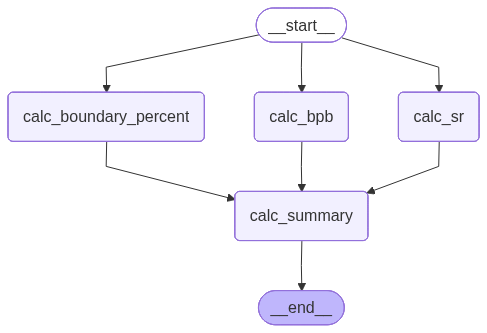

In [47]:
graph.add_edge(START,'calc_sr')
graph.add_edge(START,'calc_bpb')
graph.add_edge(START,'calc_boundary_percent')

graph.add_edge('calc_sr','calc_summary')
graph.add_edge('calc_bpb','calc_summary')
graph.add_edge('calc_boundary_percent','calc_summary')

graph.add_edge('calc_summary',END)

workflow=graph.compile()
workflow


In [48]:
initial_state={'runs':100,'balls':50,'fours':6,'sixes':4}
workflow.invoke(initial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 5.0,
 'boundary_percent': 48.0,
 'summary': '\n        Strike Rate - 200.0 \n\n        Balls per boundary - 5.0 \n\n        Boundary percent - 48.0\n    '}